In [10]:
# Cell 1 (SVM Notebook - Google Drive Loading)
from google.colab import drive
import pandas as pd

# Mount Google Drive (this will ask for permission)
drive.mount('/content/drive')

# Path to your file inside the 'ai & ml' folder
file_path = '/content/drive/MyDrive/Ai & Ml/student_performance_dataset.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully from Google Drive!")
print(f"Shape of dataset: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully from Google Drive!
Shape of dataset: (3000, 32)


,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [ ]:
# Cell 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# 1. Drop useless identifiers
df = df.drop('student_id', axis=1, errors='ignore')

# 2. Handle missing values (Impute median for numbers, mode for text)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 3. Encode Target Variable (performance_category)
le_target = LabelEncoder()
y = le_target.fit_transform(df['performance_category'])

# 4. Encode Categorical Features (One-Hot Encoding)
X = df.drop('performance_category', axis=1)
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Split into Train (70%), Validation (15%), and Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# 6. Normalize/Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val) # Standardize validation set
X_test_scaled = scaler.transform(X_test) # Standardize test set

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Validation set size: {X_val_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")

Training set size: 2099
Validation set size: 451
Test set size: 450


In [ ]:
# Cell 3
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# We must set probability=True to get probability scores later
svm = SVC(probability=True, random_state=42)

# Define Hyperparameters to tune
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3] # Only affects the 'poly' kernel
}

print("Starting Hyperparameter Tuning. This may take a few minutes...")
# Using cross-validation to find the best parameters
grid_search = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_

print("\n--- Tuning Complete ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Starting Hyperparameter Tuning. This may take a few minutes...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

--- Tuning Complete ---
Best Hyperparameters: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy: 0.9752


--- EVALUATION METRICS ---
              precision    recall  f1-score   support

        High       0.96      0.97      0.96        69
         Low       0.99      0.99      0.99       169
      Medium       0.99      0.98      0.98       212

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



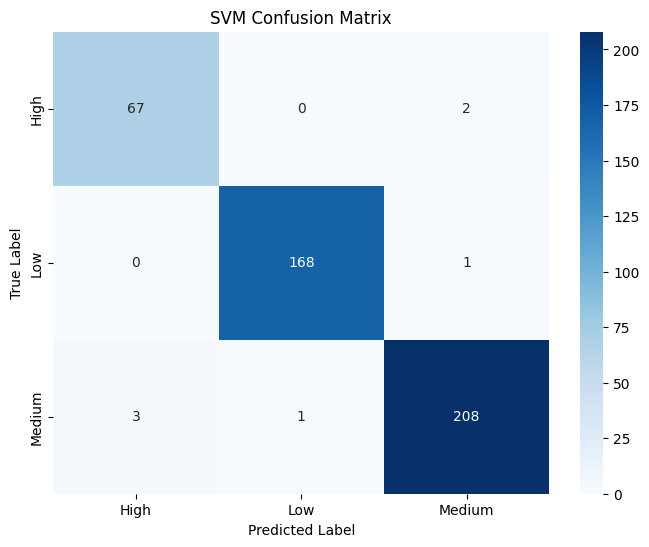

In [ ]:
# Cell 4
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the unseen Test Set
y_pred = best_svm.predict(X_test_scaled)

# 1. Classification Report (Accuracy, Precision, Recall, F1)
print("--- EVALUATION METRICS ---")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

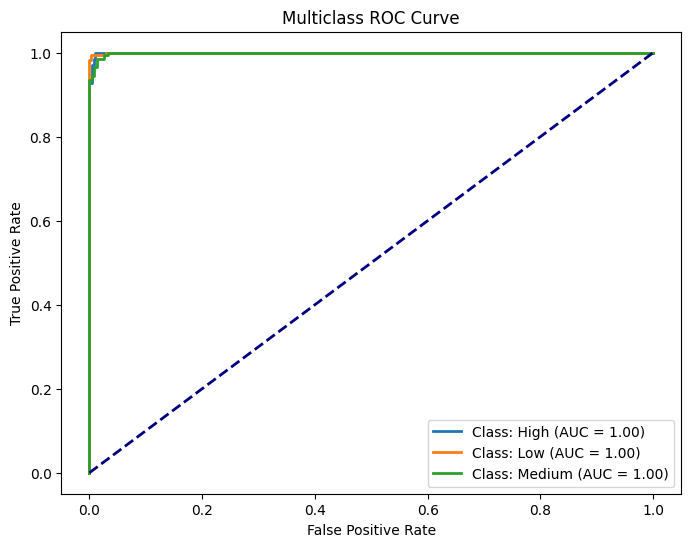

Overall AUC Score: 0.9995

--- SAMPLE PREDICTIONS (Actual vs Predicted + Probabilities) ---


,Actual,Predicted,Prob (High),Prob (Low),Prob (Medium)
0,Low,Low,1.236624e-03,9.985527e-01,2.107005e-04
1,Medium,Medium,1.623060e-02,5.373195e-04,9.832321e-01
2,Medium,Medium,3.565652e-09,4.118260e-09,1.000000e+00
3,Medium,Medium,6.047065e-04,7.245369e-02,9.269416e-01
4,Low,Low,3.662894e-06,9.985969e-01,1.399412e-03
5,Medium,Medium,1.861613e-04,1.965539e-02,9.801584e-01
6,High,High,9.998823e-01,1.174705e-04,2.434413e-07
7,Low,Low,1.034318e-03,9.988223e-01,1.434008e-04
8,Medium,Medium,1.209991e-02,8.614178e-05,9.878139e-01
9,Medium,Medium,1.727238e-05,5.675625e-03,9.943071e-01


In [ ]:
# Cell 5
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Get prediction probabilities
y_prob = best_svm.predict_proba(X_test_scaled)

# 1. Multiclass ROC/AUC Curve Preparation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class: {le_target.classes_[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Print Overall AUC
overall_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print(f"Overall AUC Score: {overall_auc:.4f}\n")

# 2. Sample Predictions output
print("--- SAMPLE PREDICTIONS (Actual vs Predicted + Probabilities) ---")
sample_results = pd.DataFrame(y_prob[:10], columns=[f'Prob ({c})' for c in le_target.classes_])
sample_results.insert(0, 'Actual', le_target.inverse_transform(y_test[:10]))
sample_results.insert(1, 'Predicted', le_target.inverse_transform(y_pred[:10]))
display(sample_results)

Generating 2D Decision Boundary Plot using PCA...


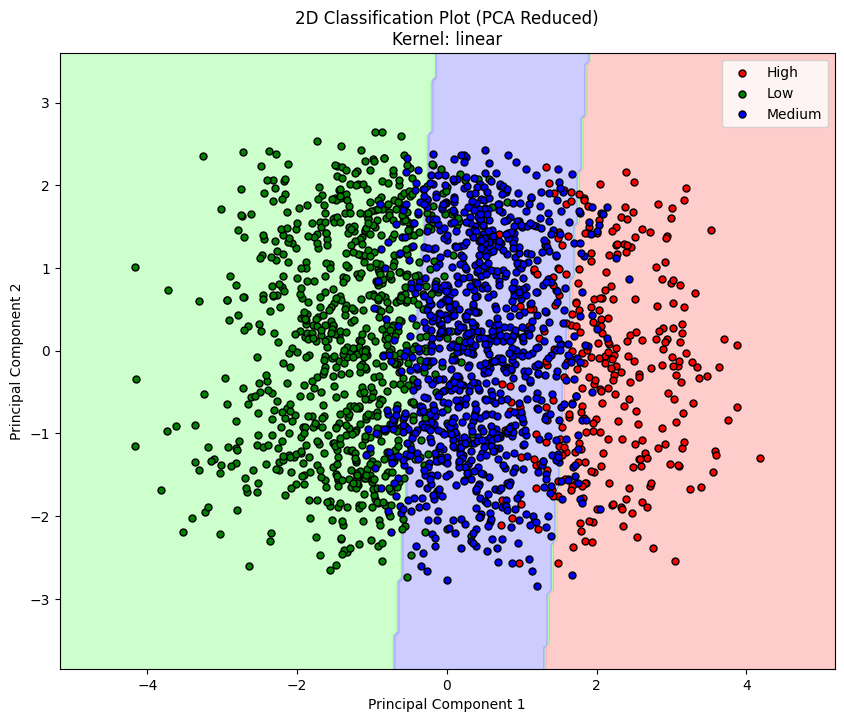

In [ ]:
# Cell 6
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

print("Generating 2D Decision Boundary Plot using PCA...")

# 1. Reduce dataset to 2 dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Train a new SVM strictly on these 2 dimensions using our best hyperparameters
best_params = grid_search.best_params_
svm_2d = SVC(kernel=best_params['kernel'], C=best_params['C'],
             gamma=best_params['gamma'], probability=False, random_state=42)
svm_2d.fit(X_train_pca, y_train)

# 3. Create a mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict across the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_light)

# Plot the training points
for i, color in zip(range(len(le_target.classes_)), cmap_bold):
    idx = np.where(y_train == i)
    plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], c=color,
                label=le_target.classes_[i], edgecolor='k', s=25)

plt.title(f"2D Classification Plot (PCA Reduced)\nKernel: {best_params['kernel']}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()